In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
pip install hampel

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
from hampel import hampel

In [4]:
import os

print(os.getcwd())
print(os.listdir("."))

C:\Users\HydroResearch\Documents\GitHub\summer_26\summer 2026
['.ipynb_checkpoints', '.~BridgeLevellogger.6.23.26.csv', '.~P1_All_6.16.csv', '.~Well_Sampling_Data_P1.csv', 'AllPTemps.ipynb', 'bell2026.yml', 'BridgeLevellogger.6.23.26.csv', 'channel 1_UTC_20260410_155519.270.xml', 'CreeksBell2026.ipynb', 'filteredhobo1.xlsx', 'GenericBell2026-Copy1.ipynb', 'GenericTESTBell2026.ipynb', 'LeveloggerFiles.ipynb', 'Manual_Data_P1.csv', 'NOAAHastingsDam2.csv', 'NOAAHastingsDam2Since2024.csv', 'P1Bell2026.ipynb', 'P1ManualData.csv', 'P1SPCBell2026.ipynb', 'P1_All_6.16.csv', 'P1_creek_current.csv', 'P1_current.csv', 'P1_Day_June15Only.csv', 'P1_Month_MayOnly.csv', 'P1_SPC_Calibration.csv', 'P2Bell2026-Copy1.ipynb', 'P2ManualData.csv', 'P2SPCBell2026.ipynb', 'P2_creek_current.csv', 'P2_current.csv', 'P3Bell2026-Copy1.ipynb', 'P3ManualData.csv', 'P3_current.csv', 'P4Bell2026.ipynb', 'P4ManualData.csv', 'P4_creek_current.csv', 'P4_current.csv', 'P5Bell2026.ipynb', 'P5ManualData.csv', 'P5_creek_cur

In [5]:
hobodf = pd.read_csv("P1_current.csv")
hobodf = hobodf.dropna()
hobodf.columns = hobodf.columns.str.strip() #This line was generated by Google Gemini to remove the leading and trailing whitespaces in the mandf dataframe. 
hobodf["Date-Time"] = pd.to_datetime(hobodf["Date-Time"])
hobodate = hobodf["Date-Time"]
slicedhobodate = hobodate[1:]
date1 = slicedhobodate.drop([36191])
date2 = date1.drop(np.arange(36192, 36211))

In [6]:
hobodf

,obs,Date-Time,Temp,Conductivity,SPC,Salinity,TDS
0,1,2024-11-06 14:16:29+00:00,13.780000,3.500000,4.500000,0.010000,2.260000
1,2,2024-11-06 14:31:29+00:00,15.170000,531.200000,669.400000,0.320000,345.270000
2,3,2024-11-06 14:46:29+00:00,15.230000,532.800000,670.400000,0.320000,346.320000
3,4,2024-11-06 15:01:29+00:00,15.190000,533.400000,671.900000,0.320000,346.720000
4,5,2024-11-06 15:16:29+00:00,15.130000,533.400000,672.800000,0.320000,346.710000
...,...,...,...,...,...,...,...
49621,13410,2026-06-16 08:29:59+00:00,11.368412,525.921143,736.855957,0.349017,341.848724
49622,13411,2026-06-16 08:44:59+00:00,11.365391,525.992493,737.021484,0.349093,341.895111
49623,13412,2026-06-16 08:59:59+00:00,11.371464,525.825867,736.656372,0.348924,341.786804
49624,13413,2026-06-16 09:14:59+00:00,11.371464,525.983521,736.877197,0.349032,341.889282


In [7]:
mandf = pd.read_csv("Manual_Data_P1.csv")
mandf

,Well,Date,Depth to water,Temp top before,Temp bottom before,SPC top before,SPC bottom before,Cond top before,Cond bottom before,Salinity top before,...,Recharge time,Temp top after,Temp bottom after,SPC top after,SPC bottom after,Cond top after,Cond bottom after,Salinity top after,Salinity bottom after,Notes
0,P1,9/16/2025 0:00,5.04,17.8,NaN,765,NaN,659,NaN,0.4,...,NaN,18.2,NaN,630.0,NaN,726.0,NaN,0.4,NaN,Recharge time too fast to measure. We pumped w...
1,P1,9/30/2025 0:00,5.06,18.9,NaN,772,796.0,683,673.0,0.4,...,NaN,19.0,17.3,677.0,648.0,765.0,760.0,0.4,0.4,Recharge time too fast to measure.
2,P1,10/7/2025 0:00,5.03,18.8,18.0,797,795.0,703,689.0,0.4,...,NaN,18.9,17.2,699.0,668.0,791.0,784.0,0.4,0.4,Recharge time too fast to measure.
3,P1,10/14/2025 0:00,5.10,17.2,17.2,819,809.0,697,687.0,0.4,...,NaN,16.9,17.1,662.0,662.0,783.0,780.0,0.4,0.4,NaN
4,P1,10/28/2025 0:00,5.09,15.0,15.7,853,844.0,691,695.0,0.4,...,NaN,15.0,15.7,653.0,647.0,808.0,787.0,0.4,0.4,Recharge time too fast to measure.
5,P1,11/4/2025 0:00,5.08,14.1,15.6,851,845.0,673,693.0,0.4,...,00:51.8,14.5,15.7,631.0,671.0,790.0,817.0,0.4,0.4,for about 0.92ft of recharge added a stick t...
6,P1,11/11/2025 0:00,5.09,13.0,15.0,867,848.0,667,686.0,0.4,...,00:47.3,13.0,14.0,821.0,799.0,633.0,634.0,0.4,0.4,NaN
7,P1,11/18/2025 0:00,5.11,12.2,14.2,865,850.0,655,674.0,0.4,...,00:45.7,12.8,14.5,803.0,828.0,615.0,661.0,0.4,0.4,NaN
8,P1,1/6/2026 0:00,NaN,6.1,9.2,824,823.0,526,576.0,0.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,P1,1/13/2026 0:00,5.17,6.0,8.9,830,819.0,530,566.0,0.4,...,00:34.0,7.2,8.9,812.0,810.0,538.0,561.0,0.4,0.4,NaN


In [8]:
print(hobodf["SPC"])

0          4.500000
1        669.400000
2        670.400000
3        671.900000
4        672.800000
            ...    
49621    736.855957
49622    737.021484
49623    736.656372
49624    736.877197
49625    736.818665
Name: SPC, Length: 49605, dtype: float64


In [9]:
#filtering the data to remove the spikes, which are the result of removing the hobo from the well during manual measurements
filteredhobo = hampel(hobodf["SPC"], window_size=6, n_sigma=1.5)
filteredhoboseries = pd.Series(filteredhobo.filtered_data, index = hobodf.index)
filteredhobo1 = filteredhoboseries[1:]
filteredhobo2 = filteredhobo1.drop([36191])
filteredhobo = filteredhobo2.drop(np.arange(36192, 36211))
# print(filteredhobo.filtered_data)

In [10]:
#type(filteredhobo)
#type(hobodate)

#filteredhobo = filteredhobo.reshape(hobodate.shape)
# filteredhoboseries = pd.Series(filteredhobo.filtered_data, index = hobodf.index)
#type(filteredhoboseries)
# filteredhobo = filteredhoboseries[1:]              #I used the google AI overview for this line of code :/

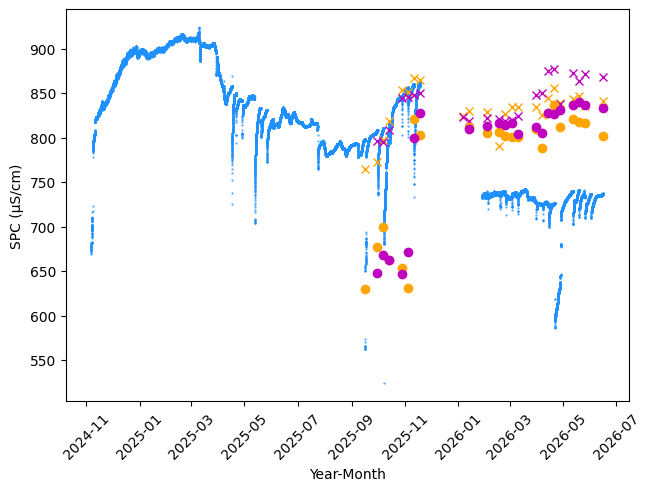

In [11]:
# hobodf.columns = hobodf.columns.str.strip() #This line was generated by Google Gemini to remove the leading and trailing whitespaces in the mandf dataframe.  
# hobodf = pd.read_csv("P1_All_6.16.csv")
mandf = pd.read_csv("Manual_Data_P1.csv")
mandf["Date"] = pd.to_datetime(mandf["Date"])

# hobodate = hobodf["Date-Time"]
# slicedhobodate = hobodate[1:]
# slicedhobodate = hobodf["Date-Time"][1:]

fig, ax = plt.subplots(layout='constrained')
ax.scatter(date2, filteredhobo, color="dodgerblue", s = 0.2, label = "HOBO continuous temperature")
ax.plot(mandf.Date, mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom before"], 'x', color = "m", label = "manual SPC at bottom before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom after"], 'o', color = "m", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
# plt.ylim((700, 750))
# plt.xlim((pd.to_datetime("2026-02"), pd.to_datetime("2026-06")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
#fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

In [12]:
hobodf = pd.read_csv("P1_All_6.16.csv")
hobodf["Date-Time (CST/CDT)"] = pd.to_datetime(hobodf["Date-Time (CST/CDT)"])
mandf = pd.read_csv("Well_Sampling_Data_P1.csv")
mandf["Date"] = pd.to_datetime(mandf["Date"])

hobodate = hobodf["Date-Time (CST/CDT)"]
slicedhobodate = hobodate[1:]

fig, ax = plt.subplots(layout='constrained')
ax.scatter(slicedhobodate, filteredhobo, s = 0.3, color="blue", label = "HOBO continuous temperature")
ax.plot(mandf.Date, mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom before"], 'x', color = "purple", label = "manual SPC at bottom before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom after"], 'o', color = "purple", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
# plt.ylim((700, 750))
# plt.xlim((pd.to_datetime("2026-02"), pd.to_datetime("2026-06")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
#fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Well_Sampling_Data_P1.csv'

In [ ]:
#finding the calibration factor
# hobodf = pd.read_csv("P1_All_6.16.csv")
# hobodf["Date-Time (CST/CDT)"] = pd.to_datetime(hobodf["Date-Time (CST/CDT)"])
# mandf = pd.read_csv("Well_Sampling_Data_P1.csv")
# mandf["Date"] = pd.to_datetime(mandf["Date"])

fig, ax = plt.subplots(layout='constrained')
ax.scatter(filteredhobo, mandf.loc[:,"SPC bottom before"], s = 0.3, color="green", label = "manual (bb) versus continuous")
# ax.plot(mandf.Date, mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
# ax.plot(mandf.Date, mandf.loc[:,"SPC bottom before"], 'x', color = "purple", label = "manual SPC at bottom before pumping")
# ax.plot(mandf.Date, mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
# ax.plot(mandf.Date, mandf.loc[:,"SPC bottom after"], 'o', color = "purple", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
# plt.xlabel("Year-Month")
# plt.ylabel("SPC (µS/cm)")
# plt.ylim((700, 750))
# plt.xlim((pd.to_datetime("2026-02"), pd.to_datetime("2026-06")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
#fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

In [ ]:
hobodf = pd.read_csv("P1_All_6.16.csv")
hobodf["Date-Time (CST/CDT)"] = pd.to_datetime(hobodf["Date-Time (CST/CDT)"])
mandf = pd.read_csv("Well_Sampling_Data_P1.csv")
mandf["Date"] = pd.to_datetime(mandf["Date"])

hobodate = hobodf["Date-Time (CST/CDT)"]
hoboSPC = hobodf["Specific Conductivity (W-CT 22414702), µS/cm"]

fig, ax = plt.subplots(layout='constrained')
ax.plot(hobodate, hoboSPC, color="blue", label = "HOBO continuous temperature")
ax.plot(mandf.Date, mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom before"], 'x', color = "purple", label = "manual SPC at bottom before pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
ax.plot(mandf.Date, mandf.loc[:,"SPC bottom after"], 'o', color = "purple", label = "manual SPC at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")

#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

In [ ]:
hobodf = pd.read_csv("P1_All_6.16.csv")
hobodf["Date-Time (CST/CDT)"] = pd.to_datetime(hobodf["Date-Time (CST/CDT)"])

hobodate = hobodf["Date-Time (CST/CDT)"]
hoboSPC = hobodf["Specific Conductivity (W-CT 22414702), µS/cm"]

fig, ax = plt.subplots(layout='constrained')
ax.plot(hobodate, hoboSPC, color="blue", label = "HOBO continuous temperature")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")

#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
fig.legend(loc='outside upper right')